In [2]:
from operator import index

import matplotlib.dates as mdates
import matplotlib.pyplot as plt

import peakweather

print("PeakWeather version ",peakweather.__version__)

from peakweather import PeakWeatherDataset

#Load Local Dataset
# Exclude: rain gauge stations (142) & sunshine variable
ds = PeakWeatherDataset(root="/Users/aureliedejong/Documents/ETH/_DAS Project/PeakWeatherDataset",
                        parameters = ["temperature",
                                      "pressure",
                                      "humidity",
                                      "wind_speed",
                                      "wind_gust",
                                      "wind_direction",
                                      "precipitation",
                                      ],
                        station_type="meteo_station")

PeakWeather version  0.2.1


### Spatial Embedding

In [15]:
print("Check number of stations:", len(ds.stations_table))

Check number of stations: 160


In [20]:
ds.stations_table.columns

Index(['station_name', 'latitude', 'longitude', 'station_height',
       'swiss_easting', 'swiss_northing', 'ASPECT_2000M_SIGRATIO1',
       'WE_DERIVATIVE_2000M_SIGRATIO1', 'TPI_2000M',
       'SN_DERIVATIVE_10000M_SIGRATIO1', 'dem',
       'SN_DERIVATIVE_2000M_SIGRATIO1', 'SLOPE_10000M_SIGRATIO1',
       'ASPECT_10000M_SIGRATIO1', 'SLOPE_2000M_SIGRATIO1', 'STD_2000M',
       'STD_10000M', 'TPI_10000M', 'WE_DERIVATIVE_10000M_SIGRATIO1',
       'station_type'],
      dtype='str')

In [32]:
station = 'ABO'

In [69]:
coordinates = ds.stations_table[['swiss_easting', 'swiss_northing']] # spatial embedding (lat, lon) → [sin(Bx), cos(Bx)]

#Call one station
ds.stations_table.loc[station]

station_name                           Adelboden
latitude                               46.491703
longitude                               7.560703
station_height                           1321.38
swiss_easting                     2609371.616986
swiss_northing                    1148939.073438
ASPECT_2000M_SIGRATIO1                124.863129
WE_DERIVATIVE_2000M_SIGRATIO1          -0.167379
TPI_2000M                             -53.303345
SN_DERIVATIVE_10000M_SIGRATIO1         -0.026807
dem                                  1317.771851
SN_DERIVATIVE_2000M_SIGRATIO1           0.116605
SLOPE_10000M_SIGRATIO1                  1.702339
ASPECT_10000M_SIGRATIO1                25.582031
SLOPE_2000M_SIGRATIO1                  11.529667
STD_2000M                             120.940262
STD_10000M                            374.830623
TPI_10000M                           -443.723877
WE_DERIVATIVE_10000M_SIGRATIO1         -0.012833
station_type                       meteo_station
Name: ABO, dtype: ob

### Temporal Embedding

In [78]:
ds.get_observations(station).head()

nat_abbr                         ABO                                        \
name                        humidity precipitation    pressure temperature   
datetime                                                                     
2017-01-01 00:00:00+00:00  30.500000           0.0  874.900024         1.1   
2017-01-01 00:10:00+00:00  30.700001           0.0  874.900024         1.2   
2017-01-01 00:20:00+00:00  34.599998           0.0  874.799988         1.2   
2017-01-01 00:30:00+00:00  27.900000           0.0  874.700012         2.0   
2017-01-01 00:40:00+00:00  32.000000           0.0  874.599976         0.5   

nat_abbr                                                       
name                      wind_direction wind_gust wind_speed  
datetime                                                       
2017-01-01 00:00:00+00:00          356.0       1.3        0.8  
2017-01-01 00:10:00+00:00          277.0       1.8        1.0  
2017-01-01 00:20:00+00:00          258.0       1.1        0.6  
2017-01-01 00:30:00+00:00          306.0       1.5        0.9  
2017-01-01 00:40:00+00:00          304.0       1.4        0.7

In [63]:
print("Start recording", ds.get_observations(station).index[0].date())
print("End recording", ds.get_observations(station).index[-1].date())

Start recording 2017-01-01
End recording 2025-10-13


In [65]:
ds.get_observations(station).index[-1] - ds.get_observations(station).index[0]

Timedelta('3207 days 23:50:00')

In [61]:
3207/365

8.786301369863013

### Variables

In [68]:
ds.get_observations(station).iloc[0]

nat_abbr  name          
ABO       humidity           30.500000
          precipitation       0.000000
          pressure          874.900024
          sunshine            0.000000
          temperature         1.100000
          wind_direction    356.000000
          wind_gust           1.300000
          wind_speed          0.800000
Name: 2017-01-01 00:00:00+00:00, dtype: float32

In [74]:
ds.available_parameters

{'temperature': 'tre200s0',
 'humidity': 'ure200s0',
 'precipitation': 'rre150z0',
 'sunshine': 'sre000z0',
 'pressure': 'prestas0',
 'wind_speed': 'fkl010z0',
 'wind_gust': 'fkl010z1',
 'wind_direction': 'dkl010z0'}

In [98]:
ds_day = PeakWeatherDataset(root="/Users/aureliedejong/Documents/ETH/_DAS Project/PeakWeatherDataset",
                        parameters = ["temperature",
                                      "pressure",
                                      "humidity",
                                      "wind_speed",
                                      "wind_gust",
                                      "wind_direction",
                                      "precipitation",
                                      ],
                        freq = "d",
                        station_type="meteo_station")

In [8]:
df, mask = ds_day.get_observations(
    #first_date="2024-08-02 16:32",
    #last_date="2024-08-06 23:26",
    return_mask=True,
)

In [14]:
mask.describe()

nat_abbr      ABO                                                              \
name     humidity precipitation pressure temperature wind_direction wind_gust   
count        3209          3209     3209        3209           3209      3209   
unique          1             2        1           1              1         1   
top          True          True     True        True           True      True   
freq         3209          3205     3209        3209           3209      3209   

nat_abbr                 AEG                         ...            WYN  \
name     wind_speed humidity precipitation pressure  ... wind_direction   
count          3209     3209          3209     3209  ...           3209   
unique            1        1             1        1  ...              1   
top            True    False         False    False  ...           True   
freq           3209     3209          3209     3209  ...           3209   

nat_abbr                           ZER                                     \
name     wind_gust wind_speed humidity precipitation pressure temperature   
count         3209       3209     3209          3209     3209        3209   
unique           1          1        2             2        2           2   
top           True       True     True          True     True        True   
freq          3209       3209     3192          3203     3203        3198   

nat_abbr                                      
name     wind_direction wind_gust wind_speed  
count              3209      3209       3209  
unique                2         2          2  
top                True      True       True  
freq               3197      3197       3197  

[4 rows x 1092 columns]

In [48]:
long_df = mask.stack(0).rename_axis(["datetime","nat_abbr"]).reset_index()

In [64]:
df_time = long_df.groupby(["datetime"]).sum().drop(columns=["nat_abbr"]).reset_index()

In [63]:
df_station = long_df.drop(columns=["datetime"]).groupby(["nat_abbr"]).sum().reset_index()

In [75]:
df_station["nat_abbr"][df_station["humidity"] == 0].values

<ArrowStringArray>
['AEG', 'BRZ', 'PRE', 'QUI', 'SCM', 'STK']
Length: 6, dtype: str

In [71]:
variables = df_station.columns[df_station.columns != 'nat_abbr']

In [79]:
dict_missing = {v: df_station["nat_abbr"][df_station[v] == 0].values for v in variables}

In [80]:
dict_missing

{'humidity': <ArrowStringArray>
 ['AEG', 'BRZ', 'PRE', 'QUI', 'SCM', 'STK']
 Length: 6, dtype: str,
 'precipitation': <ArrowStringArray>
 ['AEG', 'ATT', 'BOU', 'CMA', 'DIA', 'EGH', 'GOR', 'JUN', 'LAE', 'MRP', 'MTR',
  'NAS', 'PRE', 'QUI', 'SCM', 'STK', 'TIT']
 Length: 17, dtype: str,
 'pressure': <ArrowStringArray>
 ['AEG', 'BIN', 'BIV', 'CDM', 'COY', 'FLU', 'FRU', 'LAC', 'LAT', 'MAR', 'MAS',
  'PRE', 'SRS', 'VEV', 'VIT', 'VLS']
 Length: 16, dtype: str,
 'temperature': <ArrowStringArray>
 ['AEG', 'BRZ', 'PRE', 'QUI', 'SCM', 'STK']
 Length: 6, dtype: str,
 'wind_direction': <ArrowStringArray>
 ['GRC', 'ILZ', 'LAC', 'PSI']
 Length: 4, dtype: str,
 'wind_gust': <ArrowStringArray>
 ['GRC', 'ILZ', 'LAC', 'PSI']
 Length: 4, dtype: str,
 'wind_speed': <ArrowStringArray>
 ['GRC', 'ILZ', 'LAC', 'PSI']
 Length: 4, dtype: str}

In [81]:
df_station

name,nat_abbr,humidity,precipitation,pressure,temperature,wind_direction,wind_gust,wind_speed
0,ABO,3209,3205,3209,3209,3209,3209,3209
1,AEG,0,0,0,0,3205,3205,3205
2,AIG,3209,3209,3209,3209,3209,3209,3209
3,ALT,3209,3206,3209,3209,3209,3209,3209
4,AND,3209,3193,3209,3208,3209,3209,3209
...,...,...,...,...,...,...,...,...
151,VLS,3204,3209,0,3205,3208,3208,3208
152,WAE,3209,3198,3209,3209,3207,3205,3205
153,WFJ,3183,3131,3191,3183,3175,3175,3175
154,WYN,3209,3196,3209,3209,3209,3209,3209


In [83]:
df_station_filtered = df_station[~df_station[variables].all(axis=1)]

In [89]:
df_station_filtered

name,nat_abbr,humidity,precipitation,pressure,temperature,wind_direction,wind_gust,wind_speed
1,AEG,0,0,0,0,3205,3205,3205
8,ATT,3192,0,3209,3192,3205,3205,3205
15,BIN,3207,3203,0,3207,3208,3208,3208
16,BIV,3206,3205,0,3206,3202,3202,3202
20,BOU,3209,0,3209,3209,3209,3209,3209
22,BRZ,0,3209,3209,0,3206,3206,3206
26,CDM,3201,3206,0,3205,3200,3200,3200
36,CMA,3205,0,3209,3205,3209,3209,3209
39,COY,3208,3209,0,3205,3203,3203,3203
43,DIA,3113,0,3168,3118,3158,3158,3158


In [86]:
len(df_station)

156

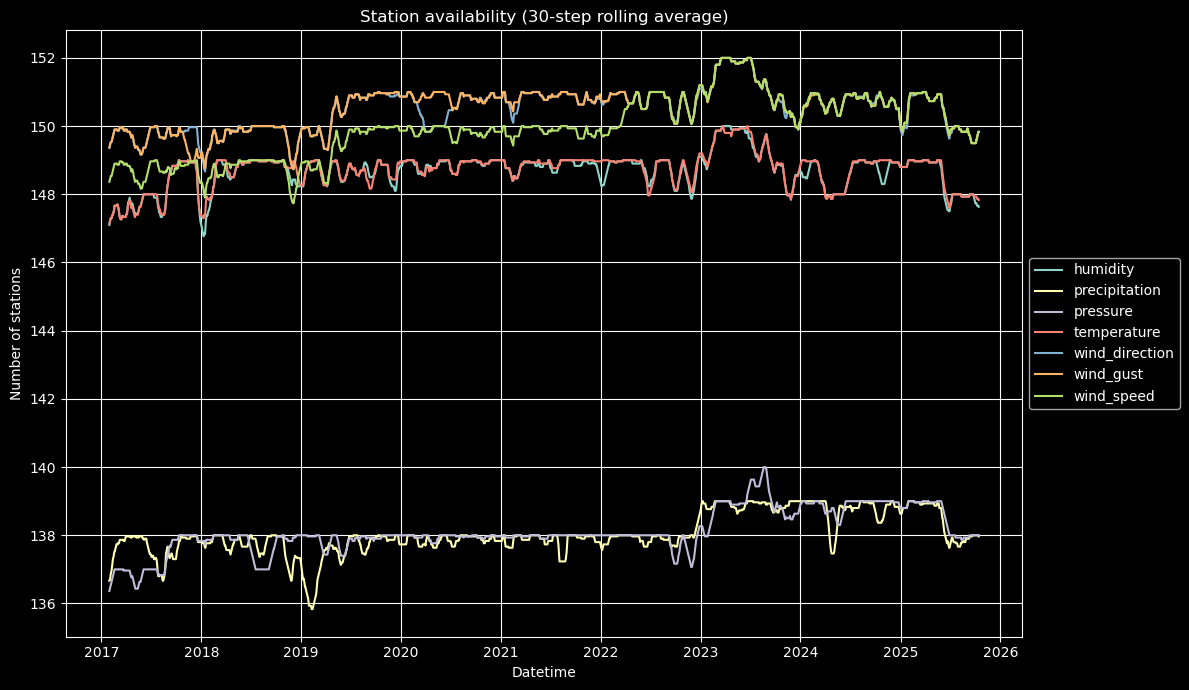

In [115]:
fig, ax = plt.subplots(figsize=(12, 7))

for v in variables:
    ax.plot(
        df_time["datetime"],
        df_time[v].rolling(30).mean(),
        label=v
    )

ax.set_title("Station availability (30-step rolling average)")
ax.set_ylabel("Number of stations")
ax.set_xlabel("Datetime")

# legend on the right side
ax.legend(loc="center left", bbox_to_anchor=(1, 0.5))

ax.grid(True)

plt.tight_layout()
plt.show()